<a href="https://colab.research.google.com/github/Ijnacio/1.4-programacion/blob/main/1_4(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd

df = pd.read_csv("titanic_data.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    object 
 3   age          713 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   embarked     887 non-null    object 
 8   class        889 non-null    object 
 9   who          889 non-null    object 
 10  adult_male   889 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  887 non-null    object 
 13  alive        889 non-null    object 
 14  alone        889 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.2+ KB


In [55]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,889.000000,889.000000,713.000000,889.000000,889.000000,889.000000
mean,0.384702,2.307087,29.698696,0.523060,0.382452,32.259059
std,0.486799,0.836367,14.536691,1.103729,0.806761,49.735870
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.000000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Resumen de Inferencias del Dataset Titanic

El dataset del Titanic contiene 889 entradas y 15 columnas.

**Valores Faltantes:**
*   `Age` (Edad): Faltan 176 valores, lo que requiere imputación o eliminación.
*   `Embarked` y `embark_town`: Faltan 2 valores en cada una, de fácil manejo.
*   `Deck` (Cubierta): Tiene una gran cantidad de valores faltantes (686), lo que dificulta su uso directo o requiere una estrategia específica.

**Tipos de Datos:**
*   Columnas numéricas: `survived`, `pclass`, `age`, `sibsp`, `parch`, `fare`.
*   Columnas categóricas: `sex`, `embarked`, `class`, `who`, `deck`, `embark_town`, `alive` (necesitan codificación).
*   Columnas booleanas: `adult_male`, `alone`.

**Estadísticas Clave:**
*   **Supervivencia:** Aproximadamente el 38.5% de los pasajeros sobrevivieron.
*   **Edad:** La edad promedio es de 29.7 años, con un rango amplio de 0.42 a 80 años.
*   **Tarifa:** La tarifa tiene una distribución muy sesgada, con un promedio de 32.26 pero un máximo de 512.33, lo que sugiere algunos billetes muy caros.

### 1. Manejo de Valores Faltantes

Comenzaremos imputando los valores faltantes en las columnas `Embarked` y `embark_town` con la moda (el valor más frecuente), ya que solo faltan 2 valores en cada una.

In [56]:
print('Valores faltantes antes de la imputación:')
display(df[['embarked', 'embark_town']].isnull().sum())

# Imputar 'Embarked' y 'embark_town' con la moda
for col in ['embarked', 'embark_town']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

print('\nValores faltantes después de la imputación:')
display(df[['embarked', 'embark_town']].isnull().sum())

Valores faltantes antes de la imputación:


,0
embarked,2
embark_town,2



Valores faltantes después de la imputación:


,0
embarked,0
embark_town,0


Ahora, imputaremos los valores faltantes en la columna `Age` con la mediana, ya que es una columna numérica y la mediana es menos sensible a los valores atípicos que la media.

In [57]:
print('Valores faltantes en Age antes de la imputación:')
display(df['age'].isnull().sum())

# Imputar 'Age' con la mediana
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

print('\nValores faltantes en Age después de la imputación:')
display(df['age'].isnull().sum())

Valores faltantes en Age antes de la imputación:


np.int64(176)


Valores faltantes en Age después de la imputación:


np.int64(0)

Para la columna `Deck`, que tiene una gran cantidad de valores faltantes, crearemos una nueva categoría 'N' (para 'None' o 'Desconocido') para mantener esta información sin eliminar la columna o los datos.

In [58]:
print('Valores faltantes en Deck antes de la imputación:')
display(df['deck'].isnull().sum())

# Imputar 'Deck' con 'N'
df['deck'] = df['deck'].fillna('N')

print('\nValores faltantes en Deck después de la imputación:')
display(df['deck'].isnull().sum())

Valores faltantes en Deck antes de la imputación:


np.int64(686)


Valores faltantes en Deck después de la imputación:


np.int64(0)

Verifiquemos que no quedan valores faltantes en el DataFrame:

In [59]:
print('Total de valores faltantes en el DataFrame después de la imputación:')
display(df.isnull().sum().sum())

Total de valores faltantes en el DataFrame después de la imputación:


np.int64(0)

### 2. Detección y Eliminación de Duplicados

Ahora, comprobaremos si hay filas duplicadas en el dataset y las eliminaremos si las encontramos para asegurar la unicidad de las observaciones.

In [60]:
print(f'Número de filas antes de eliminar duplicados: {len(df)}')

duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f'Se eliminaron {duplicates} filas duplicadas.')
else:
    print('No se encontraron filas duplicadas.')

print(f'Número de filas después de eliminar duplicados: {len(df)}')


Número de filas antes de eliminar duplicados: 889
Se eliminaron 110 filas duplicadas.
Número de filas después de eliminar duplicados: 779


### 3. Identificación de Outliers (Valores Atípicos)

Para identificar outliers en las columnas numéricas, podemos usar métodos como el diagrama de caja (boxplot) o el rango intercuartílico (IQR). A continuación, visualizaremos los outliers en las columnas `age` y `fare`.

#### Identificación de Outliers (Valores Atípicos) usando IQR

In [61]:
for col in ['age', 'fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f'\n--- Columna: {col} ---')
    print(f'Q1 (25%): {Q1}')
    print(f'Q3 (75%): {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite Inferior para Outliers: {lower_bound}')
    print(f'Límite Superior para Outliers: {upper_bound}')
    print(f'Número de Outliers en {col}: {len(outliers)}')
    print(outliers[[col]].head())


--- Columna: age ---
Q1 (25%): 21.5
Q3 (75%): 36.0
IQR: 14.5
Límite Inferior para Outliers: -0.25
Límite Superior para Outliers: 57.75
Número de Outliers en age: 33
     age
11  58.0
33  66.0
54  65.0
94  59.0
96  71.0

--- Columna: fare ---
Q1 (25%): 8.05
Q3 (75%): 34.197900000000004
IQR: 26.147900000000003
Límite Inferior para Outliers: -31.171850000000003
Límite Superior para Outliers: 73.41975000000001
Número de Outliers en fare: 102
        fare
27  263.0000
31  146.5208
34   82.1708
52   76.7292
61   80.0000


Hemos identificado los valores atípicos para `age` y `fare` utilizando el método IQR. Ahora, se podría decidir si se eliminan, se transforman o se les aplica un capping (limitar los valores extremos) dependiendo del análisis posterior.

Los puntos fuera de los 'bigotes' de los boxplots representan los valores atípicos. Podemos ver que tanto `Age` como `Fare` tienen algunos outliers. Dependiendo del análisis posterior, se podría decidir cómo tratar estos valores (por ejemplo, capping, transformación logarítmica o eliminación).

### 4. Transformaciones Avanzadas (Normalización y Encoding)

#### a) Normalización: Estandarización de `age` y `fare`

Aplicaremos la estandarización (StandardScaler) a las columnas numéricas `age` y `fare`. Esta técnica transforma los datos para que tengan una media de 0 y una desviación estándar de 1, lo cual es útil para algoritmos que asumen datos con distribución gaussiana o que son sensibles a la escala de las características, mejorando su rendimiento.

La estandarización se aplicó a 'age' y 'fare' para normalizar sus escalas, lo que es esencial para que los algoritmos de Machine Learning no favorezcan una característica sobre otra debido a la magnitud de sus valores. Esto mejora la capacidad del modelo para encontrar patrones reales en los datos, optimizando su rendimiento y evitando sesgos por diferencias de escala.

In [62]:
from sklearn.preprocessing import StandardScaler

# Inicializar el StandardScaler
scaler = StandardScaler()

# Columnas a normalizar
columns_to_normalize = ['age', 'fare']

# Aplicar la estandarización a las columnas seleccionadas
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

print('DataFrame después de la normalización (primeras 5 filas de age y fare):')
display(df[columns_to_normalize].head())

DataFrame después de la normalización (primeras 5 filas de age y fare):


,age,fare
0,-0.553562,-0.527612
1,0.608100,0.697822
2,-0.263147,-0.514694
3,0.390288,0.349840
4,0.390288,-0.512302


#### b) Encoding: Codificación One-Hot para Variables Categóricas

Convertiremos las columnas categóricas en representaciones numéricas utilizando la codificación One-Hot. Esto es esencial para que la mayoría de los modelos de aprendizaje automático puedan procesar estas características. Incluiremos columnas como `sex`, `embarked`, `class`, `who`, `deck`, `embark_town`, y `alive`.

In [63]:
# Columnas categóricas a codificar
categorical_cols = ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']

# Aplicar One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print('DataFrame después de la codificación One-Hot (primeras 5 filas con algunas columnas codificadas):')
display(df.head())

DataFrame después de la codificación One-Hot (primeras 5 filas con algunas columnas codificadas):


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,...,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_N,embark_town_Queenstown,embark_town_Southampton,alive_yes
0,0,3,-0.553562,1,0,-0.527612,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,1,1,0.608100,1,0,0.697822,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
2,1,3,-0.263147,0,0,-0.514694,False,True,False,False,...,False,False,False,False,False,False,True,False,True,True
3,1,1,0.390288,1,0,0.349840,False,False,False,False,...,False,True,False,False,False,False,False,False,True,True
4,0,3,0.390288,0,0,-0.512302,True,True,True,False,...,False,False,False,False,False,False,True,False,True,False


La codificación One-Hot se aplicó para transformar variables categóricas en un formato numérico que los modelos de Machine Learning puedan procesar. Esto evita que el modelo asuma un orden artificial entre las categorías y asegura que todas las características sean tratadas equitativamente, mejorando la capacidad predictiva del modelo.

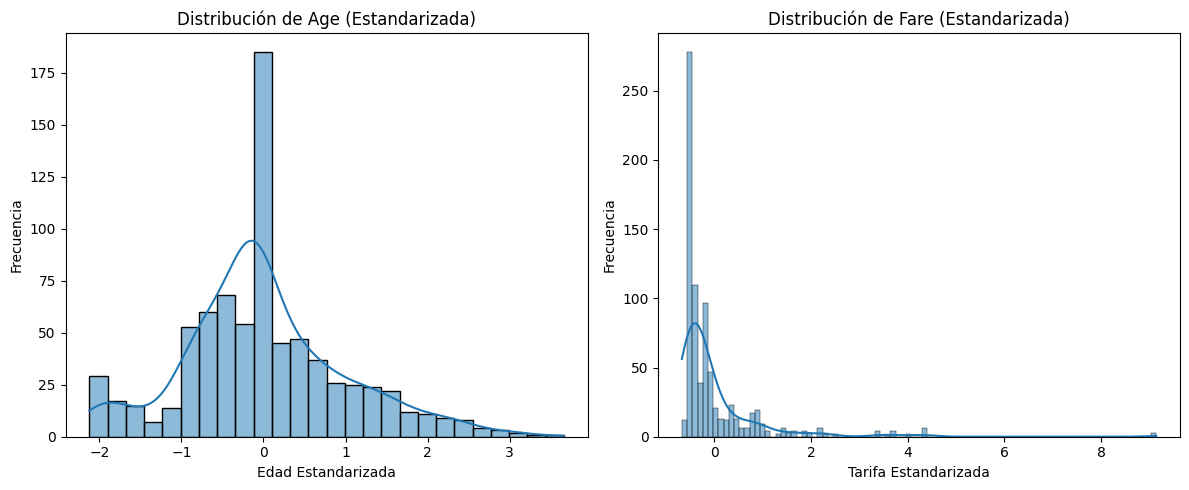

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Distribución de Age (Estandarizada)')
plt.xlabel('Edad Estandarizada')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df['fare'], kde=True)
plt.title('Distribución de Fare (Estandarizada)')
plt.xlabel('Tarifa Estandarizada')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Estas visualizaciones muestran las distribuciones de 'age' y 'fare' después de haber sido estandarizadas. Se puede observar cómo ambas columnas ahora tienen una media cercana a cero y una distribución que facilita su uso en modelos de Machine Learning, ya que sus escalas son comparables y no sesgarán el aprendizaje del modelo.

### 5. Probabilidad de Supervivencia según el Tamaño de la Familia

 `family_size` que representa el tamaño total de la familia de cada pasajero a bordo (`sibsp` + `parch` + 1). Esto nos permitirá analizar cómo el tamaño de la familia influye en la probabilidad de supervivencia.

In [67]:
# Crear la columna family_size
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Calcular la probabilidad de supervivencia según el tamaño de la familia
survival_by_family_size = df.groupby('family_size')['survived'].mean().reset_index()

print('Probabilidad de Supervivencia según el Tamaño de la Familia:')
display(survival_by_family_size)

Probabilidad de Supervivencia según el Tamaño de la Familia:


,family_size,survived
0,1,0.339367
1,2,0.555556
2,3,0.574257
3,4,0.714286
4,5,0.230769
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


Ahora, visualicemos esta probabilidad de supervivencia para comprender mejor la relación.

/tmp/ipykernel_4395/1802645746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='family_size', y='survived', data=survival_by_family_size, palette='viridis')


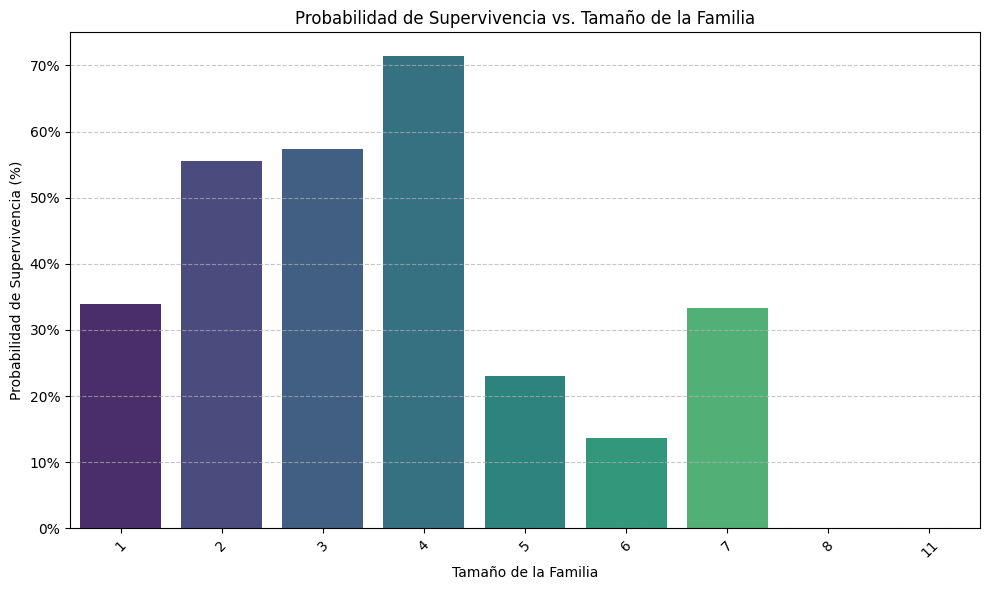

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(10, 6))
sns.barplot(x='family_size', y='survived', data=survival_by_family_size, palette='viridis')
plt.title('Probabilidad de Supervivencia vs. Tamaño de la Familia')
plt.xlabel('Tamaño de la Familia')
plt.ylabel('Probabilidad de Supervivencia (%)') # Actualizado el label
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Formatear el eje Y como porcentaje
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1)) # xmax=1 porque los valores de 'survived' ya están en un rango de 0 a 1

plt.tight_layout()
plt.show()

Esta gráfica nos muestra cómo la probabilidad de supervivencia varía con el tamaño de la familia. A menudo, se observa que las familias pequeñas tienen una mayor probabilidad de supervivencia en comparación con las personas que viajan solas o las familias muy grandes.